In [1]:
from pathlib import Path
import json
import warnings
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
print("Libraries imported successfully.")
print("LightGBM version:", lgb.__version__)

Libraries imported successfully.
LightGBM version: 4.5.0


## Project Paths

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
CANDIDATE_DIR = ARTIFACT_DIR / "candidates"
LTR_DIR = ARTIFACT_DIR / "ltr"
LTR_DIR.mkdir(parents=True,exist_ok=True)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("CANDIDATE_DIR:", CANDIDATE_DIR)
print("LTR_DIR      :", LTR_DIR)

PROJECT_ROOT : D:\iPrint-News-Recommendation-Ranking-System\Notebook
DATA_DIR     : D:\iPrint-News-Recommendation-Ranking-System\Notebook\data
CANDIDATE_DIR: D:\iPrint-News-Recommendation-Ranking-System\Notebook\artifacts\candidates
LTR_DIR      : D:\iPrint-News-Recommendation-Ranking-System\Notebook\artifacts\ltr


## Configurations

In [3]:
TARGET_K = 10
RANDOM_STATE = 42
MIN_INTERACTIONS_FOR_PERSONALIZATION = 5
VALIDATION_FRACTION = 0.20
LGB_PARAMS = {"objective": "lambdarank","metric": "ndcg","ndcg_at": [5, 10],"label_gain": [0, 1],"learning_rate": 0.05,"num_leaves": 31,"max_depth": -1,"min_child_samples": 30,"subsample": 0.8,"subsample_freq": 1,"colsample_bytree": 0.8,"reg_alpha": 0.1,"reg_lambda": 1.0,"verbosity": -1,"random_state": RANDOM_STATE,"n_jobs": -1,}
NUM_BOOST_ROUND = 500
EARLY_STOPPING_ROUNDS = 50
print(json.dumps(LGB_PARAMS, indent=4))

{
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_at": [
        5,
        10
    ],
    "label_gain": [
        0,
        1
    ],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "verbosity": -1,
    "random_state": 42,
    "n_jobs": -1
}


## Load Candidate Artifacts

In [4]:
candidate_features_path = (CANDIDATE_DIR / "candidate_features.parquet")
test_truth_path = (CANDIDATE_DIR / "test_truth.parquet")
raw_candidates_path = (CANDIDATE_DIR / "raw_candidates.parquet")
config_path = (CANDIDATE_DIR / "candidate_generation_config.json")
print("Checking files...")
for path in [candidate_features_path,test_truth_path,raw_candidates_path,]:
    print(f"{path.name}:", "found" if path.exists() else "missing")

Checking files...
candidate_features.parquet: missing
test_truth.parquet: missing
raw_candidates.parquet: missing


In [5]:
from pathlib import Path
CURRENT_DIR = Path.cwd()
print("Current working directory:")
print(CURRENT_DIR)
print("Searching for candidate_features.parquet...")
matches = list(CURRENT_DIR.parent.rglob("candidate_features.parquet"))
matches += list(CURRENT_DIR.rglob("candidate_features.parquet"))
matches = list(dict.fromkeys(matches))
if matches:
    print("Found candidate_features.parquet:")
    for path in matches:
        print("  ", path)
else:
    print("candidate_features.parquet was not found " "under the current directory.")

Current working directory:
D:\iPrint-News-Recommendation-Ranking-System\Notebook
Searching for candidate_features.parquet...
Found candidate_features.parquet:
   D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\candidate_features.parquet


In [6]:
from pathlib import Path
CURRENT_DIR = Path.cwd()
PROJECT_NAME = "iPrint-News-Recommendation-Ranking-System"
def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    search_locations = [start_path,*start_path.parents]
    for path in search_locations:
        if path.name == PROJECT_NAME:
            return path
        if ((path / "Notebook").exists() and path.name.lower().startswith("iprint")):
            return path
    return None
PROJECT_ROOT = find_project_root(CURRENT_DIR)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not automatically locate the "f"'{PROJECT_NAME}' project root.\n" f"Current directory: {CURRENT_DIR}")
print(PROJECT_ROOT)

D:\iPrint-News-Recommendation-Ranking-System


In [7]:
ARTIFACT_DIR = (PROJECT_ROOT / "artifacts")
CANDIDATE_DIR = (ARTIFACT_DIR / "candidates")
LTR_DIR = (ARTIFACT_DIR / "ltr")
LTR_DIR.mkdir(parents=True,exist_ok=True)
print("ARTIFACT_DIR :", ARTIFACT_DIR)
print("CANDIDATE_DIR:", CANDIDATE_DIR)
print("LTR_DIR :",LTR_DIR)

ARTIFACT_DIR : D:\iPrint-News-Recommendation-Ranking-System\artifacts
CANDIDATE_DIR: D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates
LTR_DIR : D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr


In [8]:
candidate_files = {"candidate_features": (CANDIDATE_DIR / "candidate_features.parquet"),"test_truth": (CANDIDATE_DIR / "test_truth.parquet"),"raw_candidates": (CANDIDATE_DIR/ "raw_candidates.parquet"),"candidate_config": (CANDIDATE_DIR / "candidate_generation_config.json"),}
print("Candidate Artifact Check")
for name, path in candidate_files.items():
    status = ("found" if path.exists() else "missing")
    print(f"{status:<12} {name:<25} {path}")

Candidate Artifact Check
found        candidate_features        D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\candidate_features.parquet
found        test_truth                D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\test_truth.parquet
found        raw_candidates            D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\raw_candidates.parquet
found        candidate_config          D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\candidate_generation_config.json


In [9]:
for filename in ["candidate_features.parquet", "test_truth.parquet", "raw_candidates.parquet","candidate_features.csv",]:
    print(filename)
    found = list(PROJECT_ROOT.rglob(filename))
    if found:
        for path in found:
            print("path")
    else:
        print("not found")

candidate_features.parquet
path
test_truth.parquet
path
raw_candidates.parquet
path
candidate_features.csv
path


## Inspect Candidates Features

In [10]:
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "iPrint-News-Recommendation-Ranking-System":
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root: ", "iPrint-News-Recommendation-Ranking-System")
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project Root:", PROJECT_ROOT)
CANDIDATE_DIR = PROJECT_ROOT / "artifacts" / "candidates"
print("Candidate Directory:", CANDIDATE_DIR)
candidate_features_path = CANDIDATE_DIR / "candidate_features.parquet"
test_truth_path = CANDIDATE_DIR / "test_truth.parquet"
raw_candidates_path = CANDIDATE_DIR / "raw_candidates.parquet"
required_files = {"candidate_features": candidate_features_path, "test_truth": test_truth_path,"raw_candidates": raw_candidates_path,}
print("\nChecking candidate artifacts...")
for name, path in required_files.items():
    print(f"{name:20s}: {path}")
    print(f"{'Exists':20s}: {path.exists()}")
    print()
missing_files = [str(path) for path in required_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError("\nMissing candidate-generation artifacts:\n" + "\n".join(f"  - {path}" for path in missing_files) + "\n\nRun Candidate_Generation.ipynb first and make sure " "the artifacts are saved under:\n" f"{CANDIDATE_DIR}")
candidate_features = pd.read_parquet(candidate_features_path)
test_truth = pd.read_parquet(test_truth_path)
raw_candidates = pd.read_parquet(raw_candidates_path)
print("Candidate artifacts loaded successfully.")
print("nShapes:")
print("candidate_features:", candidate_features.shape)
print("test_truth:", test_truth.shape)
print("raw_candidates:", raw_candidates.shape)

Project Root: D:\iPrint-News-Recommendation-Ranking-System
Candidate Directory: D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates

Checking candidate artifacts...
candidate_features  : D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\candidate_features.parquet
Exists              : True

test_truth          : D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\test_truth.parquet
Exists              : True

raw_candidates      : D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates\raw_candidates.parquet
Exists              : True

Candidate artifacts loaded successfully.
nShapes:
candidate_features: (514172, 12)
test_truth: (1715, 2)
raw_candidates: (924719, 10)


In [11]:
CANDIDATE_DIR = PROJECT_ROOT / "artifacts" / "candidates"
CANDIDATE_DIR.mkdir(parents=True, exist_ok=True)
raw_candidates.to_parquet(CANDIDATE_DIR / "raw_candidates.parquet", index=False)
candidate_features.to_parquet(CANDIDATE_DIR / "candidate_features.parquet", index=False)
candidate_features.to_csv(CANDIDATE_DIR / "candidate_features.csv", index=False)
test_truth.to_parquet(CANDIDATE_DIR / "test_truth.parquet", index=False)
print("Candidate artifacts saved to:")
print(CANDIDATE_DIR)

Candidate artifacts saved to:
D:\iPrint-News-Recommendation-Ranking-System\artifacts\candidates


## Load Candidate Generation Configurations

In [12]:
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        candidate_config = json.load(f)
    print(json.dumps(candidate_config, indent=4, default=str))
else:
    candidate_config = {}
    print("candidate_generation_config.json not found.")

candidate_generation_config.json not found.


## Basic Validations

In [13]:
required_base_columns = ["consumer_id", "item_id",]
missing_base_columns = [col for col in required_base_columns  if col not in candidate_features.columns]
if missing_base_columns:
    raise ValueError("Missing required columns: "  f"{missing_base_columns}")
print("Base columns available")
print("Unique users:", candidate_features["consumer_id"].nunique())
print("Unique candidate articles:", candidate_features["item_id"].nunique())
print("Total candidate rows:", len(candidate_features))

Base columns available
Unique users: 1715
Unique candidate articles: 2901
Total candidate rows: 514172


## Normalize ID

In [14]:
candidate_features["consumer_id"] = (candidate_features["consumer_id"].astype(str).str.strip())
candidate_features["item_id"] = (candidate_features["item_id"].astype(str).str.strip())
raw_candidates["consumer_id"] = (raw_candidates["consumer_id"].astype(str).str.strip())
raw_candidates["item_id"] = (raw_candidates["item_id"].astype(str).str.strip())
if "consumer_id" in test_truth.columns:
    test_truth["consumer_id"] = (test_truth["consumer_id"].astype(str).str.strip())
if "item_id" in test_truth.columns:
    test_truth["item_id"] = (test_truth["item_id"].astype(str).str.strip())
print("IDs normalized")

IDs normalized


In [15]:
display(test_truth.head(20))
print("test_truth columns:", test_truth.columns.tolist())

,consumer_id,item_id
0,-1007001694607905623,8729086959762650511
1,-1032019229384696495,3566197569262766169
2,-108842214936804958,-4029704725707465084
3,-1093393486211919385,-3191013159715472435
4,-1110220372195277179,-1297580205670251233
5,-1113322110177216831,-5953227649059336919
6,-1119397949556155765,-2402288292108892893
7,-1130272294246983140,8477804012624580461
8,-1157793243708252831,-6872546942144599345
9,-1160159014793528221,-3462051751080362224


test_truth columns: ['consumer_id', 'item_id']


## 1. Build Held Out Truth Mappings

In [16]:
if {"consumer_id", "item_id"}.issubset(test_truth.columns):
    test_truth_map = (test_truth.groupby("consumer_id")["item_id"].apply(set).to_dict())
else:
    raise ValueError("test_truth must contain consumer_id and item_id.")
print("Users with held-out truth:", len(test_truth_map))
example_user = next(iter(test_truth_map))
print("Example user:", example_user)
print("Held-out items:", test_truth_map[example_user])

Users with held-out truth: 1715
Example user: -1007001694607905623
Held-out items: {'8729086959762650511'}


## 2. Create LTR Label

In [17]:
candidate_features["label"] = [int(item_id in test_truth_map.get(user_id,set())) for user_id, item_id in zip(candidate_features["consumer_id"],candidate_features["item_id"])]
print("Label distribution:")
print(candidate_features["label"].value_counts().sort_index())
print("Positive examples:",int(candidate_features["label"].sum()))
print("Positive rate:",f"{candidate_features['label'].mean():.6%}")

Label distribution:
label
0    513524
1       648
Name: count, dtype: int64
Positive examples: 648
Positive rate: 0.126028%


In [18]:
positive_rows = candidate_features[candidate_features["label"] == 1]
print("Positive rows:", len(positive_rows))
print("Users having at least one positive candidate:", positive_rows["consumer_id"].nunique())
truth_users = set(test_truth_map.keys())
candidate_users = set(candidate_features["consumer_id"])
print("Truth users:", len(truth_users))
print("Candidate users:", len(candidate_users))
missing_truth_users = (truth_users - candidate_users)
print("Truth users without candidates:", len(missing_truth_users))

Positive rows: 648
Users having at least one positive candidate: 648
Truth users: 1715
Candidate users: 1715
Truth users without candidates: 0


In [19]:
positive_coverage = (positive_rows["consumer_id"].nunique() / len(truth_users))
print(f"Candidate positive coverage: "f"{positive_coverage:.4%}")

Candidate positive coverage: 37.7843%


## 3. Check Duplicates User Item Candidates

In [20]:
duplicate_mask = candidate_features.duplicated(subset=["consumer_id","item_id",],keep=False)
duplicate_count = int(duplicate_mask.sum())
print("Duplicate user-item candidate rows:",duplicate_count)
if duplicate_count > 0:
    display(candidate_features[duplicate_mask].sort_values(["consumer_id","item_id"]).head(20))

Duplicate user-item candidate rows: 0


## 4. Required Ranking Features

In [21]:
candidate_score_features = ["popularity_score","trending_score","country_score","tfidf_score","cf_score","als_score","semantic_score"]
article_features = ["freshness_score",]
structural_features = ["num_sources",]
ranking_features = (candidate_score_features + article_features + structural_features)
print("Ranking features:")
for feature in ranking_features:
    print(" -", feature)

Ranking features:
 - popularity_score
 - trending_score
 - country_score
 - tfidf_score
 - cf_score
 - als_score
 - semantic_score
 - freshness_score
 - num_sources


## 5. Add Candiates Quality Features

In [22]:
score_cols = [col for col in candidate_score_features if col in candidate_features.columns]
candidate_features["source_count"] = (candidate_features[score_cols].notna().sum(axis=1))
candidate_features["score_sum"] = (candidate_features[score_cols].fillna(0).sum(axis=1))
candidate_features["score_mean"] = (candidate_features[score_cols].replace(0, np.nan).mean(axis=1))
candidate_features["score_max"] = (candidate_features[score_cols].fillna(0).max(axis=1))
candidate_features["score_min"] = (candidate_features[score_cols].fillna(0).min(axis=1))
ranking_features += ["source_count","score_sum","score_mean","score_max","score_min",]
print("Total ranking features:", len(ranking_features))

Total ranking features: 14


## 6. Missing Values Treatments

In [23]:
print("Available candidate_features columns")
for i, col in enumerate(candidate_features.columns, 1):
    print(f"{i:03d}. {col}")

Available candidate_features columns
001. consumer_id
002. item_id
003. popularity_score
004. trending_score
005. country_score
006. tfidf_score
007. cf_score
008. als_score
009. semantic_score
010. candidate_priority
011. group_id
012. label
013. source_count
014. score_sum
015. score_mean
016. score_max
017. score_min


In [24]:
score_columns = ["popularity_score", "trending_score", "country_score", "tfidf_score", "cf_score", "als_score", "semantic_score",]
existing_score_columns = [col for col in score_columns if col in candidate_features.columns]
candidate_features["num_sources"] = (candidate_features[existing_score_columns].notna().sum(axis=1))
if "freshness_score" not in candidate_features.columns:
    if "article_published_at" in candidate_features.columns:
        candidate_features["article_published_at"] = pd.to_datetime(candidate_features["article_published_at"],utc=True,errors="coerce")
        reference_time = train_consumer["event_datetime"].max()
        candidate_features["article_age_days"] = ((reference_time - candidate_features["article_published_at"]).dt.total_seconds()  / 86400.0).clip(lower=0)
        candidate_features["freshness_score"] = (0.5 ** (candidate_features["article_age_days"] / 14.0))
    else:
        print("article_published_at is not available. " "freshness_score cannot be calculated.")
print("Ranking features checked.")
print("Created / available:")
for col in ["num_sources", "article_age_days", "freshness_score"]:
    print(f"{col:25s}: " f"{'YES' if col in candidate_features.columns else 'NO'}")

article_published_at is not available. freshness_score cannot be calculated.
Ranking features checked.
Created / available:
num_sources              : YES
article_age_days         : NO
freshness_score          : NO


In [25]:
missing_features = [feature for feature in ranking_features if feature in candidate_features.columns]
missing_from_dataframe = [feature for feature in ranking_features if feature not in candidate_features.columns]
if missing_from_dataframe:
    print("Features not found in candidate_features:")
    for feature in missing_from_dataframe:
        print(f"   - {feature}")
missing_summary = (candidate_features[missing_features].isna().mean().sort_values(ascending=False).to_frame("missing_rate"))
display(missing_summary)

Features not found in candidate_features:
   - freshness_score


,missing_rate
semantic_score,1.000000
trending_score,0.863674
tfidf_score,0.784243
country_score,0.743592
als_score,0.739657
cf_score,0.738156
popularity_score,0.734120
score_mean,0.006060
num_sources,0.000000
source_count,0.000000


## 7. Add User Level Features

In [26]:
possible_user_features = ["user_interaction_count","user_unique_articles","user_activity_count","user_unique_items","user_avg_interaction_strength","user_recency",]
existing_user_features = [col for col in possible_user_features if col in candidate_features.columns]
print("Existing user features:")
for col in existing_user_features:
    print(" -", col)

Existing user features:


## 8. Add Available User Features To Ranking Features

In [27]:
for col in existing_user_features:
    if col not in ranking_features:
        ranking_features.append(col)
print("Final feature count:", len(ranking_features))

Final feature count: 14


## 9. Producers Features

In [28]:
possible_producer_features = ["producer_affinity","producer_interaction_count","producer_user_interaction_count","producer_popularity",]
existing_producer_features = [col for col in possible_producer_features if col in candidate_features.columns]
print("Producer features:")
for col in existing_producer_features:
    print(" -", col)
for col in existing_producer_features:
    if col not in ranking_features:
        ranking_features.append(col)

Producer features:


In [29]:
possible_session_features = ["session_interaction_count","session_unique_items","session_category_affinity",]
existing_session_features = [col for col in possible_session_features if col in candidate_features.columns]
print("Session features:")
for col in existing_session_features:
    print(" -", col)
for col in existing_session_features:
    if col not in ranking_features:
        ranking_features.append(col)

Session features:


## 10. Final Features List

In [30]:
ranking_features = list(dict.fromkeys(ranking_features))
print(f"Number of LTR features: "f"{len(ranking_features)}")
for i, feature in enumerate(ranking_features,1):
    print(f"{i:02d}. {feature}")

Number of LTR features: 14
01. popularity_score
02. trending_score
03. country_score
04. tfidf_score
05. cf_score
06. als_score
07. semantic_score
08. freshness_score
09. num_sources
10. source_count
11. score_sum
12. score_mean
13. score_max
14. score_min


## 11. Check Infinities

In [31]:
current_path = Path.cwd().resolve()
PROJECT_ROOT = None
for path in [current_path, *current_path.parents]:
    if path.name == "iPrint-News-Recommendation-Ranking-System":
        PROJECT_ROOT = path
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root: ""iPrint-News-Recommendation-Ranking-System")
print("Project root:", PROJECT_ROOT)
possible_content_paths = [PROJECT_ROOT / "data" / "platform_content.csv",PROJECT_ROOT / "Data" / "platform_content.csv",PROJECT_ROOT / "platform_content.csv",PROJECT_ROOT / "Notebook" / "platform_content.csv"]
CONTENT_PATH = next((path for path in possible_content_paths if path.exists()),None)
if CONTENT_PATH is None:
    matches = list(PROJECT_ROOT.rglob("platform_content.csv"))
    if not matches:
        raise FileNotFoundError("platform_content.csv could not be found "f"inside:\n{PROJECT_ROOT}")
    CONTENT_PATH = matches[0]
print("Content data:", CONTENT_PATH)
content_ltr = pd.read_csv(CONTENT_PATH)
required_content_columns = {"item_id","interaction_type","event_timestamp",}
missing = (required_content_columns - set(content_ltr.columns))
if missing:
    raise ValueError("platform_content.csv is missing columns: "  + ", ".join(sorted(missing)))
content_ltr["event_timestamp"] = pd.to_numeric(content_ltr["event_timestamp"],errors="coerce")
content_ltr["event_datetime"] = pd.to_datetime(content_ltr["event_timestamp"],unit="s",utc=True,errors="coerce")
article_first_present = (content_ltr.loc[content_ltr["interaction_type"].astype(str).str.strip().eq("content_present"),["item_id","event_datetime",],].dropna(subset=["item_id","event_datetime"]).sort_values(["item_id", "event_datetime"]).drop_duplicates( subset=["item_id"], keep="first").rename(columns={"event_datetime":"article_published_at"}))
print("Articles with publication time:", len(article_first_present))
candidate_features = (candidate_features.copy())
candidate_features["item_id"] = (candidate_features["item_id"].astype(str).str.strip())
article_first_present["item_id"] = (article_first_present["item_id"].astype(str).str.strip())
columns_to_remove = ["article_published_at","article_age_days","freshness_score"]
candidate_features = (candidate_features.drop(columns=[col for col in columns_to_remove if col in candidate_features.columns], errors="ignore"))
candidate_features = (candidate_features.merge(article_first_present, on="item_id", how="left", validate="many_to_one"))
reference_time = None
if ("train_consumer" in globals() and isinstance(train_consumer, pd.DataFrame) and "event_datetime" in train_consumer.columns):
    train_times = pd.to_datetime(train_consumer["event_datetime"], utc=True, errors="coerce")
    reference_time = train_times.max()
if (reference_time is None or pd.isna(reference_time)):
    possible_consumer_paths = [PROJECT_ROOT  / "data" / "consumer_transanctions.csv", PROJECT_ROOT / "Data" / "consumer_transanctions.csv", PROJECT_ROOT / "consumer_transanctions.csv", PROJECT_ROOT / "Notebook" / "consumer_transanctions.csv"]
    CONSUMER_PATH = next((path for path in possible_consumer_paths  if path.exists()),None,)
    if CONSUMER_PATH is None:
        matches = list(PROJECT_ROOT.rglob("consumer_transanctions.csv"))
        if matches:
            CONSUMER_PATH = matches[0]
    if CONSUMER_PATH is None:
        raise FileNotFoundError(
            "Could not determine reference time "
            "because consumer_transanctions.csv "
            "was not found."
        )
    consumer_ltr = pd.read_csv(CONSUMER_PATH,usecols=["event_timestamp"])
    consumer_ltr["event_timestamp"] = (pd.to_numeric(consumer_ltr["event_timestamp"],errors="coerce"))
    consumer_times = pd.to_datetime(consumer_ltr["event_timestamp"],unit="s", utc=True, errors="coerce")
    reference_time = (consumer_times.max())
if pd.isna(reference_time):
    raise ValueError("Could not determine a valid reference time.")
print("Freshness reference time:", reference_time)
candidate_features["article_age_days"] = ((reference_time  - candidate_features["article_published_at"]).dt.total_seconds().div(86400.0))
candidate_features["article_age_days"] = (candidate_features["article_age_days"].clip(lower=0))
FRESHNESS_HALF_LIFE_DAYS = 14.0
candidate_features["freshness_score"] = np.power(0.5,candidate_features["article_age_days"] / FRESHNESS_HALF_LIFE_DAYS)
assert ("freshness_score" in candidate_features.columns)
print("freshness_score created successfully")
print("candidate_features shape:", candidate_features.shape)
print("Missing publication timestamps:", candidate_features["article_published_at"].isna().sum())
print("Missing freshness scores:", candidate_features["freshness_score"].isna().sum())
display(candidate_features[["item_id","article_published_at","article_age_days","freshness_score",]].head(10))

Project root: D:\iPrint-News-Recommendation-Ranking-System
Content data: D:\iPrint-News-Recommendation-Ranking-System\Dataset\platform_content.csv
Articles with publication time: 3047
Freshness reference time: 2017-02-28 19:21:51+00:00
freshness_score created successfully
candidate_features shape: (514172, 21)
Missing publication timestamps: 0
Missing freshness scores: 0


,item_id,article_published_at,article_age_days,freshness_score
0,-1038011342017850,2016-05-17 16:50:00+00:00,287.105451,6.708380e-07
1,-1101361754763388054,2016-12-07 12:42:59+00:00,83.276991,1.619445e-02
2,-115909536143817330,2017-02-03 13:18:04+00:00,25.252627,2.864273e-01
3,-1199490911632553070,2016-06-29 11:47:16+00:00,244.315683,5.580709e-06
4,-1254906787526072320,2016-06-02 16:11:44+00:00,271.132025,1.479383e-06
5,-1291869519847635026,2016-08-28 13:51:07+00:00,184.229676,1.093119e-04
6,-1297580205670251233,2016-07-11 14:36:58+00:00,232.197836,1.016832e-05
7,-133139342397538859,2016-07-06 14:02:08+00:00,237.222025,7.928996e-06
8,-1443900796086927361,2016-09-20 21:18:24+00:00,160.919062,3.466533e-04
9,-1444481301861872291,2016-04-28 14:23:28+00:00,306.207211,2.605487e-07


In [32]:
print("LTR Feature Validation")
missing_features = []
for feature in ranking_features:
    if feature in candidate_features.columns:
        print(f"{feature}")
    else:
        print(f"{feature}")
        missing_features.append(feature)
if missing_features:
    raise ValueError("Still missing ranking features: " + ", ".join(missing_features))
print(f"All {len(ranking_features)} ""ranking features are available.")

LTR Feature Validation
popularity_score
trending_score
country_score
tfidf_score
cf_score
als_score
semantic_score
freshness_score
num_sources
source_count
score_sum
score_mean
score_max
score_min
All 14 ranking features are available.


In [33]:
X = candidate_features[ranking_features].copy()
y = candidate_features["label"].astype(np.int8)
print("Feature matrix created")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive labels:", int(y.sum()))
print("Positive rate:", round(float(y.mean()), 6))

Feature matrix created
X shape: (514172, 14)
y shape: (514172,)
Positive labels: 648
Positive rate: 0.00126


In [34]:
missing_features = [feature for feature in ranking_features if feature not in candidate_features.columns]
if missing_features:
    raise ValueError("Missing ranking features:\n" + "\n".join( f"  - {feature}" for feature in missing_features))
X = candidate_features[ranking_features].copy()
y = candidate_features["label"].astype(int)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive labels:", y.sum())
print("Positive rate:", round(y.mean(), 6))

X shape: (514172, 14)
y shape: (514172,)
Positive labels: 648
Positive rate: 0.00126


## 12. Convert Features To Numeric

In [35]:
non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric features:", non_numeric_features)

Non-numeric features: []


In [36]:
for col in ranking_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")
print("Ranking matrix converted to numeric.")

Ranking matrix converted to numeric.


## 13. User Level Train & Validation Splits

In [37]:
rng = np.random.default_rng(RANDOM_STATE)
all_users = (candidate_features["consumer_id"].drop_duplicates().to_numpy())
rng.shuffle(all_users)
n_validation_users = int(len(all_users) * VALIDATION_FRACTION)
validation_users = set(all_users[:n_validation_users])
train_users = set(all_users[n_validation_users:])
print("Total users:", len(all_users))
print("Training users:", len(train_users))
print("Validation users:", len(validation_users))

Total users: 1715
Training users: 1372
Validation users: 343


In [38]:
train_mask = (candidate_features["consumer_id"].isin(train_users))
validation_mask = (candidate_features["consumer_id"].isin(validation_users))
X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_valid = X.loc[validation_mask].copy()
y_valid = y.loc[validation_mask].copy()
train_meta = candidate_features.loc[train_mask].copy()
valid_meta = candidate_features.loc[validation_mask].copy()
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Train positives:", y_train.sum())
print("Validation positives:", y_valid.sum())

X_train: (411374, 14)
X_valid: (102798, 14)
Train positives: 522
Validation positives: 126


In [39]:
train_order = np.argsort(train_meta["consumer_id"].astype(str).to_numpy())
valid_order = np.argsort(valid_meta["consumer_id"].astype(str).to_numpy())
X_train = X_train.iloc[train_order].reset_index(drop=True)
y_train = y_train.iloc[train_order].reset_index(drop=True)
train_meta = train_meta.iloc[train_order].reset_index(drop=True)
X_valid = X_valid.iloc[valid_order].reset_index(drop=True)
y_valid = y_valid.iloc[valid_order].reset_index(drop=True)
valid_meta = valid_meta.iloc[valid_order].reset_index(drop=True)

## 14. Calculate LightGBM Groups

In [40]:
train_groups = (train_meta.groupby("consumer_id",sort=False).size().to_numpy())
valid_groups = (valid_meta.groupby("consumer_id",sort=False).size().to_numpy())
print("Training groups:", len(train_groups))
print("Validation groups:", len(valid_groups))
print("Training rows:", train_groups.sum())
print("Validation rows:", valid_groups.sum())
assert (train_groups.sum() == len(X_train))
assert (valid_groups.sum() == len(X_valid))

Training groups: 1372
Validation groups: 343
Training rows: 411374
Validation rows: 102798


## 15. Check Groups With Positives

In [41]:
train_group_positive = (train_meta.assign(label=y_train.to_numpy()).groupby("consumer_id")["label"].sum())
valid_group_positive = (valid_meta.assign(label=y_valid.to_numpy()).groupby("consumer_id")["label"].sum())
print("Train users with positive:", (train_group_positive > 0).sum())
print("Train users without positive:", (train_group_positive == 0).sum())
print("Validation users with positive:", (valid_group_positive > 0).sum())
print("Validation users without positive:", (valid_group_positive == 0).sum())

Train users with positive: 522
Train users without positive: 850
Validation users with positive: 126
Validation users without positive: 217


## 16. Check Validation User Without Positives

In [42]:
valid_users_with_positive = set(valid_group_positive[valid_group_positive > 0].index)
valid_keep_mask = (valid_meta["consumer_id"].isin(valid_users_with_positive))
X_valid = X_valid.loc[valid_keep_mask].reset_index(drop=True)
y_valid = y_valid.loc[valid_keep_mask].reset_index(drop=True)
valid_meta = valid_meta.loc[valid_keep_mask].reset_index(drop=True)
valid_groups = (valid_meta.groupby("consumer_id",sort=False).size().to_numpy())
print("Final validation users:", valid_meta["consumer_id"].nunique())
print("Final validation rows:", len(X_valid))
print("Final validation positives:", y_valid.sum())

Final validation users: 126
Final validation rows: 37715
Final validation positives: 126


## 17. Train LightGBM LambdaMART

In [43]:
train_dataset = lgb.Dataset(X_train,label=y_train,group=train_groups,feature_name=ranking_features,free_raw_data=False,)
valid_dataset = lgb.Dataset(X_valid,label=y_valid,group=valid_groups,feature_name=ranking_features,reference=train_dataset,free_raw_data=False)
print("Training LightGBM LambdaMART...")
ltr_model = lgb.train(params=LGB_PARAMS, train_set=train_dataset, num_boost_round=NUM_BOOST_ROUND, valid_sets=[train_dataset, valid_dataset],valid_names=["train","valid"],callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS),lgb.log_evaluation(period=100)])
print("Best iteration:", ltr_model.best_iteration)

Training LightGBM LambdaMART...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[21]	train's ndcg@5: 0.763429	train's ndcg@10: 0.778403	valid's ndcg@5: 0.311936	valid's ndcg@10: 0.347565
Best iteration: 21


## 18. Model Informations

In [44]:
print("Best iteration:", ltr_model.best_iteration)
print("Number of features:", ltr_model.num_feature())
print("Features:")
for feature in ltr_model.feature_name():
    print(" -",feature)

Best iteration: 21
Number of features: 14
Features:
 - popularity_score
 - trending_score
 - country_score
 - tfidf_score
 - cf_score
 - als_score
 - semantic_score
 - freshness_score
 - num_sources
 - source_count
 - score_sum
 - score_mean
 - score_max
 - score_min


## 19. Predict Validation Scores

In [45]:
valid_meta["ltr_score"] = (ltr_model.predict(X_valid, num_iteration=ltr_model.best_iteration))
display(valid_meta[["consumer_id", "item_id","label","ltr_score"]].sort_values(["consumer_id","ltr_score"],ascending=[True,False]).head(50))

,consumer_id,item_id,label,ltr_score
283,-1278786815002349091,-4029704725707465084,1,1.071584
20,-1278786815002349091,1469580151036142903,0,0.548781
79,-1278786815002349091,3714350889740403446,0,0.280570
196,-1278786815002349091,-14569272361926584,0,0.197711
273,-1278786815002349091,-4132331404553626868,0,0.166796
267,-1278786815002349091,-4333957157636611418,0,0.158606
128,-1278786815002349091,2581138407738454418,0,0.157771
47,-1278786815002349091,-6783772548752091658,0,0.109053
214,-1278786815002349091,-2402288292108892893,0,0.106863
37,-1278786815002349091,-7264217791213422584,0,0.098927


## 20. Ranking Evaluation

In [46]:
def dcg_at_k(relevances, k=10):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum((2 ** relevances - 1) / discounts)
def ndcg_at_k(relevances, k=10):
    relevances = np.asarray(relevances)
    actual_dcg = dcg_at_k(relevances, k)
    ideal_relevances = np.sort(relevances)[::-1]
    ideal_dcg = dcg_at_k(ideal_relevances, k)
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg
def recall_at_k(relevances, k=10):
    relevances = np.asarray(relevances)
    total_relevant = (relevances > 0).sum()
    if total_relevant == 0:
        return 0.0
    retrieved_relevant = (relevances[:k] > 0).sum()
    return (retrieved_relevant / total_relevant)
def precision_at_k(relevances, k=10):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    return ((relevances > 0).sum() / k)
def mrr_at_k(relevances, k=10):
    relevances = np.asarray(relevances)[:k]
    positive_positions = np.where(relevances > 0)[0]
    if len(positive_positions) == 0:
        return 0.0
    return 1.0 / (positive_positions[0] + 1)

## 21. Evaluate LTR

In [47]:
def evaluate_ranking(df,score_column,label_column="label",user_column="consumer_id",k=10,):
    metrics = []
    for user_id, group in df.groupby(user_column):
        ranked = (group.sort_values(score_column,ascending=False))
        relevance = ranked[label_column].to_numpy()
        metrics.append({"consumer_id": user_id, "ndcg": ndcg_at_k(relevance,k),"recall": recall_at_k(relevance,k),"precision": precision_at_k(relevance,k),"mrr": mrr_at_k(relevance,k),})
    metrics_df = pd.DataFrame(metrics)
    summary = {f"NDCG@{k}": metrics_df["ndcg"].mean(),f"Recall@{k}": metrics_df["recall"].mean(),f"Precision@{k}": metrics_df["precision"].mean(),f"MRR@{k}": metrics_df["mrr"].mean(),}
    return (pd.DataFrame([summary]),metrics_df)
ltr_metrics, ltr_user_metrics = (evaluate_ranking(valid_meta,score_column="ltr_score", k=TARGET_K,))
display(ltr_metrics)

,NDCG@10,Recall@10,Precision@10,MRR@10
0,0.349859,0.531746,0.053175,0.294432


## 22. Add Baseline Scores

In [48]:
baseline_columns = ["popularity_score","trending_score","country_score","tfidf_score","cf_score","als_score","semantic_score"]
available_baselines = [col for col in baseline_columns if col in valid_meta.columns]
print("Available baselines:")
for col in available_baselines:
    print(" -", col)

Available baselines:
 - popularity_score
 - trending_score
 - country_score
 - tfidf_score
 - cf_score
 - als_score
 - semantic_score


## 23. Evaluate All Baselines

In [49]:
evaluation_rows = []
for score_column in (available_baselines + ["ltr_score"]):
    temp = valid_meta[["consumer_id","item_id","label",score_column]].copy()
    temp[score_column] = (temp[score_column].fillna(0))
    metrics, _ = evaluate_ranking(temp,score_column=score_column,k=TARGET_K)
    row = metrics.iloc[0].to_dict()
    row["model"] = score_column
    evaluation_rows.append(row)
baseline_results = pd.DataFrame(evaluation_rows)
baseline_results = baseline_results[["model",f"NDCG@{TARGET_K}",f"Recall@{TARGET_K}",f"Precision@{TARGET_K}",f"MRR@{TARGET_K}"]].sort_values(f"NDCG@{TARGET_K}",ascending=False)
display(baseline_results)

,model,NDCG@10,Recall@10,Precision@10,MRR@10
7,ltr_score,0.349859,0.531746,0.053175,0.294432
2,country_score,0.245608,0.293651,0.029365,0.231337
5,als_score,0.133819,0.238095,0.023810,0.102368
1,trending_score,0.126591,0.309524,0.030952,0.070953
0,popularity_score,0.084648,0.246032,0.024603,0.041046
4,cf_score,0.030293,0.087302,0.008730,0.014204
3,tfidf_score,0.028276,0.063492,0.006349,0.017634
6,semantic_score,0.012971,0.023810,0.002381,0.009952


## 24. Improvement Over Stongest Baseline

In [50]:
ltr_row = baseline_results[baseline_results["model"] == "ltr_score"].iloc[0]
non_ltr_results = baseline_results[baseline_results["model"] != "ltr_score"]
best_baseline_row = (non_ltr_results.sort_values(f"NDCG@{TARGET_K}",ascending=False).iloc[0])
best_baseline_ndcg = (best_baseline_row[f"NDCG@{TARGET_K}"])
ltr_ndcg = (ltr_row[f"NDCG@{TARGET_K}"])
absolute_improvement = (ltr_ndcg - best_baseline_ndcg)
relative_improvement = (absolute_improvement / best_baseline_ndcg if best_baseline_ndcg > 0 else np.nan)
print("Best baseline:", best_baseline_row["model"])
print("Best baseline NDCG@10:", best_baseline_ndcg)
print("LTR NDCG@10:", ltr_ndcg)
print("Absolute improvement:", absolute_improvement)
print("Relative improvement:", relative_improvement)

Best baseline: country_score
Best baseline NDCG@10: 0.2456081181295846
LTR NDCG@10: 0.3498590697742037
Absolute improvement: 0.10425095164461912
Relative improvement: 0.42446052857917166


In [51]:
feature_importance = pd.DataFrame({"feature": ltr_model.feature_name(),"importance_gain": ltr_model.feature_importance(importance_type="gain"),"importance_split": ltr_model.feature_importance(importance_type="split")}).sort_values("importance_gain",ascending=False)
display(feature_importance)

,feature,importance_gain,importance_split
7,freshness_score,10497.300709,150
8,num_sources,5275.345848,37
5,als_score,2507.267650,111
2,country_score,1850.424240,67
4,cf_score,978.437712,47
10,score_sum,846.858888,41
1,trending_score,815.949688,31
11,score_mean,720.112565,45
3,tfidf_score,673.072931,49
0,popularity_score,476.314861,32


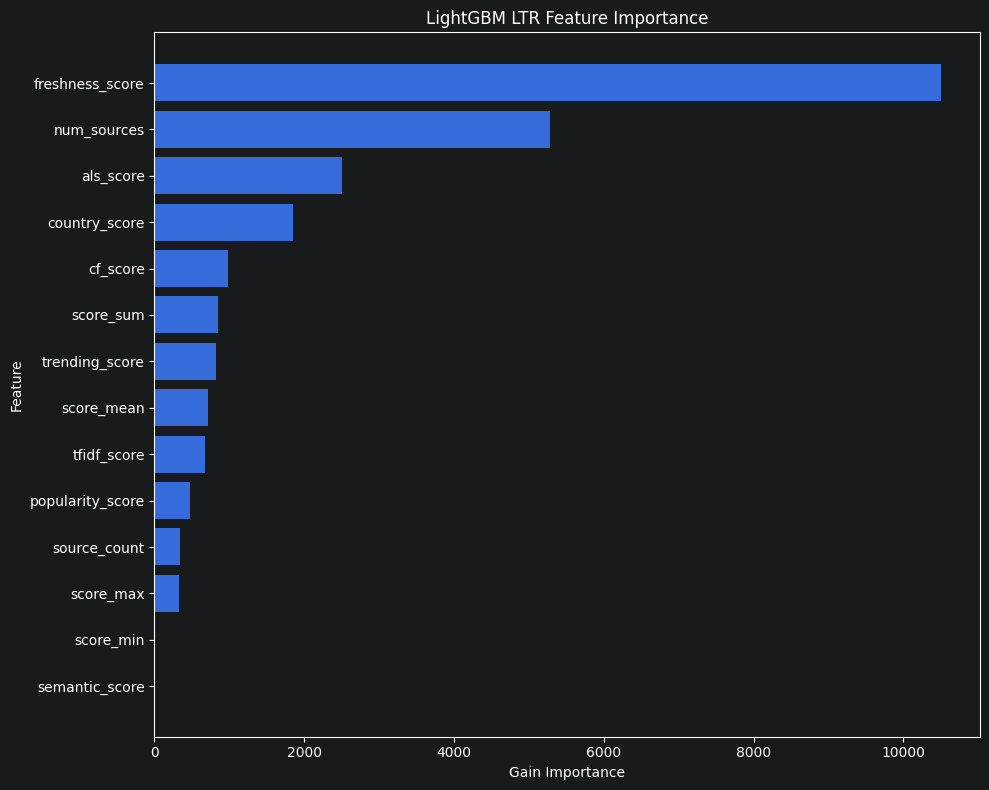

In [52]:
top_features = (feature_importance.head(20).sort_values("importance_gain"))
plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance_gain"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("LightGBM LTR Feature Importance")
plt.tight_layout()
plt.show()

In [55]:
inspect_user = (valid_meta["consumer_id"].iloc[0])
user_candidates = (valid_meta[valid_meta["consumer_id"] == inspect_user].copy())
user_candidates = (user_candidates.sort_values("ltr_score",ascending=False))
display(user_candidates[["item_id","title","language","label","ltr_score","popularity_score","trending_score","country_score","tfidf_score","cf_score","als_score","semantic_score","freshness_score","num_sources"]].head(30))

,item_id,title,language,label,ltr_score,popularity_score,trending_score,country_score,tfidf_score,cf_score,als_score,semantic_score,freshness_score,num_sources
283,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,en,1,1.071584,0.959645,0.612633,1.000000,NaN,NaN,NaN,NaN,5.438496e-01,3
20,1469580151036142903,Don't document your code. Code your documentation.,en,0,0.548781,0.864398,NaN,0.633887,NaN,NaN,0.008895,NaN,5.078919e-01,3
79,3714350889740403446,Python - It's metaclasses all the way down,en,0,0.280570,NaN,NaN,NaN,NaN,0.182574,0.008218,NaN,3.879638e-01,2
196,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,en,0,0.197711,NaN,0.317465,0.376547,0.066022,NaN,0.013917,NaN,3.484181e-01,4
273,-4132331404553626868,Gartner Reprint,en,0,0.166796,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,7.395302e-01,1
267,-4333957157636611418,Why Programmers Want Private Offices,en,0,0.158606,0.890566,NaN,0.764085,NaN,NaN,NaN,NaN,1.850964e-03,2
128,2581138407738454418,10 Modern Software Over-Engineering Mistakes,en,0,0.157771,0.963692,NaN,0.716951,NaN,NaN,NaN,NaN,2.763430e-05,2
47,-6783772548752091658,Livro: Retrospectivas Divertidas,pt,0,0.109053,1.000000,NaN,0.774551,NaN,NaN,NaN,NaN,1.450455e-05,2
214,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,pt,0,0.106863,NaN,0.606408,NaN,NaN,NaN,NaN,NaN,6.690312e-01,1
37,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,pt,0,0.098927,NaN,0.195287,NaN,NaN,NaN,NaN,NaN,6.690029e-01,1


In [54]:
if "valid_meta" not in globals():
    raise NameError("valid_meta is not defined. " "Run the LTR prediction/validation cell first.")
current_path = Path.cwd().resolve()
PROJECT_ROOT = None
for path in [current_path, *current_path.parents]:
    if path.name == "iPrint-News-Recommendation-Ranking-System":
        PROJECT_ROOT = path
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root.")
content_matches = list(PROJECT_ROOT.rglob("platform_content.csv"))
if not content_matches:
    raise FileNotFoundError("platform_content.csv was not found inside:\n" f"{PROJECT_ROOT}")
CONTENT_PATH = content_matches[0]
print("Content file:", CONTENT_PATH)
content = pd.read_csv(CONTENT_PATH)
print("Content shape:",content.shape)
article_metadata = (content[["item_id","title","language"]].drop_duplicates(subset=["item_id"]).copy())
valid_meta = valid_meta.copy()
valid_meta["item_id"] = (valid_meta["item_id"].astype(str).str.strip())
article_metadata["item_id"] = (article_metadata["item_id"].astype(str).str.strip())
valid_meta = valid_meta.drop(columns=["title","language"],errors="ignore")
valid_meta = valid_meta.merge(article_metadata,on="item_id",how="left",validate="many_to_one")
if valid_meta.empty:
    raise ValueError("valid_meta is empty. " "There are no candidates to inspect.")
inspect_user = (valid_meta["consumer_id"].iloc[0])
user_candidates = (valid_meta[valid_meta["consumer_id"] == inspect_user].copy())
if "ltr_score" not in user_candidates.columns:
    raise ValueError("'ltr_score' is missing from valid_meta. " "Run the LTR prediction cell first.")
user_candidates = (user_candidates.sort_values("ltr_score",ascending=False))
display_columns = ["item_id","title","language","label","ltr_score","popularity_score","trending_score","country_score","tfidf_score","cf_score","als_score","semantic_score","freshness_score","num_sources"]
available_display_columns = [col  for col in display_columns  if col in user_candidates.columns]
missing_display_columns = [col for col in display_columns if col not in user_candidates.columns]
if missing_display_columns:
    print("Missing display columns:")
    for col in missing_display_columns:
        print(f"   - {col}")
print(f"User: {inspect_user}")
print(f"Candidate count: " f"{len(user_candidates)}")
print(f"Showing top " f"{min(30, len(user_candidates))} candidates:")
display(user_candidates[available_display_columns].head(30))

Content file: D:\iPrint-News-Recommendation-Ranking-System\Dataset\platform_content.csv
Content shape: (3122, 13)
User: -1278786815002349091
Candidate count: 300
Showing top 30 candidates:


,item_id,title,language,label,ltr_score,popularity_score,trending_score,country_score,tfidf_score,cf_score,als_score,semantic_score,freshness_score,num_sources
283,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,en,1,1.071584,0.959645,0.612633,1.000000,NaN,NaN,NaN,NaN,5.438496e-01,3
20,1469580151036142903,Don't document your code. Code your documentation.,en,0,0.548781,0.864398,NaN,0.633887,NaN,NaN,0.008895,NaN,5.078919e-01,3
79,3714350889740403446,Python - It's metaclasses all the way down,en,0,0.280570,NaN,NaN,NaN,NaN,0.182574,0.008218,NaN,3.879638e-01,2
196,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,en,0,0.197711,NaN,0.317465,0.376547,0.066022,NaN,0.013917,NaN,3.484181e-01,4
273,-4132331404553626868,Gartner Reprint,en,0,0.166796,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,7.395302e-01,1
267,-4333957157636611418,Why Programmers Want Private Offices,en,0,0.158606,0.890566,NaN,0.764085,NaN,NaN,NaN,NaN,1.850964e-03,2
128,2581138407738454418,10 Modern Software Over-Engineering Mistakes,en,0,0.157771,0.963692,NaN,0.716951,NaN,NaN,NaN,NaN,2.763430e-05,2
47,-6783772548752091658,Livro: Retrospectivas Divertidas,pt,0,0.109053,1.000000,NaN,0.774551,NaN,NaN,NaN,NaN,1.450455e-05,2
214,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,pt,0,0.106863,NaN,0.606408,NaN,NaN,NaN,NaN,NaN,6.690312e-01,1
37,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,pt,0,0.098927,NaN,0.195287,NaN,NaN,NaN,NaN,NaN,6.690029e-01,1


## 25. Show Only Recommended Top 10

In [56]:
top10 = (user_candidates.head(10)[["item_id","title","ltr_score","label"]])
display(top10)

,item_id,title,ltr_score,label
283,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,1.071584,1
20,1469580151036142903,Don't document your code. Code your documentation.,0.548781,0
79,3714350889740403446,Python - It's metaclasses all the way down,0.280570,0
196,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,0.197711,0
273,-4132331404553626868,Gartner Reprint,0.166796,0
267,-4333957157636611418,Why Programmers Want Private Offices,0.158606,0
128,2581138407738454418,10 Modern Software Over-Engineering Mistakes,0.157771,0
47,-6783772548752091658,Livro: Retrospectivas Divertidas,0.109053,0
214,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,0.106863,0
37,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,0.098927,0


## 26. Show Whether Held Out Articles Was Retrieved

In [57]:
positive_candidates = (user_candidates[user_candidates["label"] == 1])
if positive_candidates.empty:
    print("Held-out article was NOT present in the candidate set.")
else:
    positive_item = (positive_candidates.iloc[0]["item_id"])
    positive_rank = (user_candidates.reset_index(drop=True).index[user_candidates.reset_index(drop=True)["item_id"] == positive_item][0] + 1)
    print("Held-out item:", positive_item)
    print("LTR rank:", positive_rank)
    print("In Top-10:", positive_rank <= 10)

Held-out item: -4029704725707465084
LTR rank: 1
In Top-10: True


## 27. Analyze Rank Distribution

In [58]:
positive_ranks = []
for user_id, group in valid_meta.groupby("consumer_id"):
    ranked = (group.sort_values("ltr_score",ascending=False).reset_index(drop=True))
    positive_indices = np.where(ranked["label"].to_numpy() == 1)[0]
    if len(positive_indices) > 0:
        positive_ranks.append(positive_indices[0] + 1)
rank_distribution = pd.Series(positive_ranks,name="positive_rank")
display(rank_distribution.describe())

count    126.000000
mean      31.936508
std       49.806465
min        1.000000
25%        2.000000
50%        9.500000
75%       40.250000
max      293.000000
Name: positive_rank, dtype: float64

## 28. Hit Rate Metrics

In [59]:
for k in [1, 3, 5, 10, 20, 50]:
    hit_rate = (rank_distribution <= k).mean()
    print(f"Hit Rate@{k}: " f"{hit_rate:.4%}")

Hit Rate@1: 21.4286%
Hit Rate@3: 32.5397%
Hit Rate@5: 41.2698%
Hit Rate@10: 53.1746%
Hit Rate@20: 66.6667%
Hit Rate@50: 80.1587%


## 29. Candidates Recall Ceiling

In [60]:
candidate_recall_values = []
for user_id, truth_items in test_truth_map.items():
    user_candidates = set(candidate_features.loc[candidate_features["consumer_id"]  == user_id,"item_id"])
    if len(truth_items) == 0:
        continue
    recall = (len(truth_items & user_candidates) / len(truth_items))
    candidate_recall_values.append(recall)
candidate_recall_ceiling = np.mean(candidate_recall_values)
print("Candidate Recall Ceiling:", f"{candidate_recall_ceiling:.4%}")

Candidate Recall Ceiling: 37.7843%


## 30. Source Contributions Analyis

In [61]:
source_columns = {"Popularity": "popularity_score","Trending": "trending_score","Country": "country_score","TF-IDF": "tfidf_score","Item-CF": "cf_score","ALS": "als_score","Semantic": "semantic_score"}
source_analysis = []
for source_name, score_col in source_columns.items():
    if score_col not in candidate_features.columns:
        continue
    source_rows = (candidate_features[score_col].notna())
    positive_source_rows = (candidate_features.loc[source_rows,"label"].sum())
    source_analysis.append({"source": source_name,"candidate_rows": int(source_rows.sum()),"positive_candidates": int(positive_source_rows),"positive_rate": (positive_source_rows / source_rows.sum() if source_rows.sum() > 0 else 0),})
source_analysis_df = pd.DataFrame(source_analysis)
display(source_analysis_df.sort_values("positive_rate",ascending=False))

,source,candidate_rows,positive_candidates,positive_rate
1,Trending,70095,261,0.003724
2,Country,131838,395,0.002996
5,ALS,133861,365,0.002727
0,Popularity,136708,299,0.002187
4,Item-CF,134633,171,0.001270
3,TF-IDF,110936,81,0.000730
6,Semantic,0,0,0.000000


## 31. Final Recommendation Functions

In [62]:
def rank_candidates_for_user(user_id,candidate_df,model,feature_columns,top_k=10,):
    user_df = (candidate_df[candidate_df["consumer_id"] == str(user_id)].copy())
    if user_df.empty:
        return pd.DataFrame()
    X_user = user_df[feature_columns].copy()
    for col in feature_columns:
        X_user[col] = pd.to_numeric(X_user[col],errors="coerce")
    user_df["ltr_score"] = (model.predict(X_user,num_iteration=model.best_iteration))
    user_df = (user_df.sort_values("ltr_score",ascending=False).head(top_k).reset_index(drop=True))
    user_df["rank"] = (np.arange(len(user_df)) + 1)
    return user_df

## 32. Test Ranking Function

In [63]:
recommendations = (rank_candidates_for_user(user_id=inspect_user,candidate_df=valid_meta,model=ltr_model,feature_columns=ranking_features,top_k=10))
display(recommendations[["rank","item_id","title","ltr_score"]])

,rank,item_id,title,ltr_score
0,1,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,1.071584
1,2,1469580151036142903,Don't document your code. Code your documentation.,0.548781
2,3,3714350889740403446,Python - It's metaclasses all the way down,0.280570
3,4,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,0.197711
4,5,-4132331404553626868,Gartner Reprint,0.166796
5,6,-4333957157636611418,Why Programmers Want Private Offices,0.158606
6,7,2581138407738454418,10 Modern Software Over-Engineering Mistakes,0.157771
7,8,-6783772548752091658,Livro: Retrospectivas Divertidas,0.109053
8,9,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,0.106863
9,10,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,0.098927


In [64]:
final_recommendations = recommendations[["rank", "item_id", "title"]].copy()
final_recommendations.columns = ["rank","article_id","article_title"]
display(final_recommendations)

,rank,article_id,article_title
0,1,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life
1,2,1469580151036142903,Don't document your code. Code your documentation.
2,3,3714350889740403446,Python - It's metaclasses all the way down
3,4,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement
4,5,-4132331404553626868,Gartner Reprint
5,6,-4333957157636611418,Why Programmers Want Private Offices
6,7,2581138407738454418,10 Modern Software Over-Engineering Mistakes
7,8,-6783772548752091658,Livro: Retrospectivas Divertidas
8,9,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test
9,10,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?


## 33. Diversity Aware Reranking

In [65]:
def diversify_by_producer(ranked_df,top_k=10,producer_column="producer_id",max_per_producer=2,):
    if ranked_df.empty:
        return ranked_df.copy()
    selected = []
    producer_counts = {}
    for _, row in ranked_df.iterrows():
        producer = row.get(producer_column,None)
        current_count = (producer_counts.get(producer,0))
        if current_count >= max_per_producer:
            continue
        selected.append(row)
        producer_counts[producer] = current_count + 1
        if len(selected) >= top_k:
            break
    result = pd.DataFrame(selected).reset_index(drop=True)
    result["rank"] = (np.arange(len(result)) + 1)
    return result

In [68]:

if "recommendations" not in globals():
    raise NameError("recommendations is not defined Run the LTR recommendation generation cell first.")
if "producer_id" not in recommendations.columns:
    print("producer_id is missing from recommendations.")
    if "content" not in globals():
        raise NameError("producer_id is missing and content is not loaded. Load platform_content.csv first.")
    producer_metadata = (content[["item_id","producer_id"]].drop_duplicates(subset=["item_id"]).copy())
    recommendations = recommendations.copy()
    recommendations["item_id"] = (recommendations["item_id"].astype(str).str.strip())
    producer_metadata["item_id"] = (producer_metadata["item_id"].astype(str).str.strip())
    recommendations = recommendations.merge(producer_metadata,on="item_id",how="left",validate="many_to_one")
    print("producer_id added to recommendations.")
if "producer_id" not in recommendations.columns:
    raise ValueError("producer_id could not be added to recommendations.")
diverse_recommendations = (diversify_by_producer(recommendations,top_k=10,producer_column="producer_id",max_per_producer=2))
if "rank" not in diverse_recommendations.columns:
    diverse_recommendations = (diverse_recommendations.reset_index(drop=True))
    diverse_recommendations["rank"] = (diverse_recommendations.index + 1)
display(diverse_recommendations[["rank","item_id","title","ltr_score","producer_id"]])

,rank,item_id,title,ltr_score,producer_id
0,1,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,1.071584,6013226412048763966
1,2,1469580151036142903,Don't document your code. Code your documentation.,0.548781,-4465926797008424436
2,3,3714350889740403446,Python - It's metaclasses all the way down,0.280570,-534549863526737439
3,4,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,0.197711,-8781306637602263252
4,5,-4132331404553626868,Gartner Reprint,0.166796,9109075639526981934
5,6,-4333957157636611418,Why Programmers Want Private Offices,0.158606,-7496361692498935601
6,7,2581138407738454418,10 Modern Software Over-Engineering Mistakes,0.157771,6756039155228175109
7,8,-6783772548752091658,Livro: Retrospectivas Divertidas,0.109053,4918484843075254252
8,9,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,0.106863,-4465926797008424436
9,10,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,0.098927,6013226412048763966


## 34. Evaluate Top 10 After Diversity

In [70]:
def evaluate_diversified_ranking(df,model,feature_columns,k=10,producer_column="producer_id"):
    results = []
    for user_id, group in df.groupby("consumer_id"):
        X_user = group[feature_columns].copy()
        for col in feature_columns:
            X_user[col] = pd.to_numeric(X_user[col],errors="coerce")
        group = group.copy()
        group["ltr_score"] = (model.predict(X_user,num_iteration=model.best_iteration))
        ranked = (group.sort_values("ltr_score",ascending=False))
        diversified = (diversify_by_producer(ranked,top_k=k,producer_column=producer_column,max_per_producer=2))
        relevance = diversified["label"].to_numpy()
        results.append({"consumer_id": user_id,"ndcg": ndcg_at_k(relevance,k),"recall": recall_at_k(relevance,k),"mrr": mrr_at_k(relevance,k)})
    result_df = pd.DataFrame(results)
    return {f"NDCG@{k}": result_df["ndcg"].mean(),f"Recall@{k}": result_df["recall"].mean(),f"MRR@{k}": result_df["mrr"].mean()}
diversified_metrics = (evaluate_diversified_ranking(valid_meta,ltr_model,ranking_features,k=10))
print(diversified_metrics)

{'NDCG@10': 0.24432998826530752, 'Recall@10': 0.2619047619047619, 'MRR@10': 0.23809523809523808}


## 35. Compare Raw Vs Diversified

In [72]:
comparison = pd.DataFrame([{"model": "LTR",**ltr_metrics.iloc[0].to_dict()},{"model": "LTR + Diversity",**diversified_metrics}])
display(comparison)

,model,NDCG@10,Recall@10,Precision@10,MRR@10
0,LTR,0.349859,0.531746,0.053175,0.294432
1,LTR + Diversity,0.244330,0.261905,NaN,0.238095


## 36. Train Final Model

In [74]:
final_candidate_features = candidate_features.copy()
final_X = final_candidate_features[ranking_features].copy()
final_y = final_candidate_features["label"].astype(int)
for col in ranking_features:
    final_X[col] = pd.to_numeric(final_X[col],errors="coerce")
final_meta = final_candidate_features[["consumer_id","item_id"]].copy()
final_order = np.argsort(final_meta["consumer_id"].astype(str).to_numpy())
final_X = final_X.iloc[final_order].reset_index(drop=True)
final_y = final_y.iloc[final_order].reset_index(drop=True)
final_meta = final_meta.iloc[final_order].reset_index(drop=True)
final_groups = (final_meta.groupby("consumer_id",sort=False).size().to_numpy())
print("Final training rows:", len(final_X))
print("Final training users:", len(final_groups))
print("Final positive labels:", final_y.sum())

Final training rows: 514172
Final training users: 1715
Final positive labels: 648


## 37. Final LightGBM For Dataset

In [76]:
final_dataset = lgb.Dataset(final_X,label=final_y,group=final_groups,feature_name=ranking_features,free_raw_data=False)
print("Final LightGBM dataset created.")

Final LightGBM dataset created.


## Final Model Parameters

In [78]:
best_iteration = (ltr_model.best_iteration)
print("Validation-selected boosting rounds:",best_iteration)
if best_iteration is None:
    best_iteration = NUM_BOOST_ROUND

Validation-selected boosting rounds: 21


## Train Final LTR Model

In [79]:
final_ltr_model = lgb.train(params=LGB_PARAMS,train_set=final_dataset,num_boost_round=best_iteration,callbacks=[lgb.log_evaluation(period=50)])
print("Final LTR model trained.")

Final LTR model trained.


## Save Model

In [81]:
model_path = (LTR_DIR / "lightgbm_ltr_model.txt")
final_ltr_model.save_model(str(model_path))
print("Saved:", model_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\lightgbm_ltr_model.txt


## Save Features List

In [83]:
feature_config = {"model_type": "LightGBM LambdaMART","objective": "lambdarank","target_k": TARGET_K,"features": ranking_features,"best_iteration": int(best_iteration),"random_state": RANDOM_STATE}
feature_config_path = (LTR_DIR / "ltr_feature_config.json")
with open(feature_config_path,"w",encoding="utf-8") as f:
    json.dump(feature_config,f,indent=4)
print("Saved:", feature_config_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\ltr_feature_config.json


## Save Feature Importance

In [85]:
feature_importance_path = (LTR_DIR / "feature_importance.csv")
feature_importance.to_csv(feature_importance_path,index=False)
print("Saved:", feature_importance_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\feature_importance.csv


## Save Evaluation Results

In [87]:
evaluation_path = (LTR_DIR  / "ranking_evaluation.csv")
baseline_results.to_csv(evaluation_path,index=False)
print("Saved:", evaluation_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\ranking_evaluation.csv


## Save Validation Recommendations

In [89]:
validation_predictions_path = (LTR_DIR / "validation_predictions.parquet")
valid_meta.to_parquet(validation_predictions_path,index=False)
print("Saved:", validation_predictions_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\validation_predictions.parquet


## Save Final Configuration

In [91]:
complete_config = {"project": "iPrint News Recommendation & Ranking System","model": {"type": "LightGBM","objective": "lambdarank","best_iteration": int(best_iteration),"parameters": LGB_PARAMS},"ranking": {"top_k": TARGET_K,"features": ranking_features},"evaluation": {"candidate_recall_ceiling": float(candidate_recall_ceiling),"ltr_ndcg_at_10": float(ltr_ndcg),"best_baseline": str(best_baseline_row["model"]),"best_baseline_ndcg_at_10": float(best_baseline_ndcg)},"artifacts": {"model": str(model_path),"feature_config": str(feature_config_path),"feature_importance": str(feature_importance_path),"evaluation": str(evaluation_path)}}
complete_config_path = (LTR_DIR / "ltr_config.json")
with open(complete_config_path, "w",encoding="utf-8") as f:
    json.dump(complete_config,f,indent=4,default=str)
print("Saved:",complete_config_path)

Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\ltr_config.json


## Load Model Test

In [93]:
loaded_ltr_model = lgb.Booster(model_file=str(model_path))
print("Saved model successfully reloaded.")
print("Loaded model features:", loaded_ltr_model.num_feature())

Saved model successfully reloaded.
Loaded model features: 14


## Inference Test

In [96]:
if "candidate_features" not in globals():
    raise NameError("candidate_features is not defined Run the candidate loading/feature engineering cells first.")
if "loaded_ltr_model" not in globals():
    raise NameError("loaded_ltr_model is not defined. Load the trained LTR model first.")
if "ranking_features" not in globals():
    raise NameError("ranking_features is not defined.")
if "final_meta" in globals() and not final_meta.empty:
    production_test_user = (final_meta["consumer_id"].iloc[0])
else:
    production_test_user = (candidate_features["consumer_id"].iloc[0])
print("Production test user:", production_test_user)
production_candidates = (candidate_features[candidate_features["consumer_id"] == production_test_user].copy())
if production_candidates.empty:
    raise ValueError(f"No candidates found for user " f"{production_test_user}.")
missing_features = [col for col in ranking_features if col not in production_candidates.columns]
if missing_features:
    raise ValueError("Missing ranking features:\n" + "\n".join(f"  - {col}" for col in missing_features))
production_X = (production_candidates[ranking_features].copy())
for col in ranking_features:
    production_X[col] = pd.to_numeric(production_X[col], errors="coerce")
production_X = production_X.replace([np.inf, -np.inf], np.nan)
production_candidates["ranking_score"] = loaded_ltr_model.predict(production_X)
production_recommendations = (production_candidates.sort_values("ranking_score",ascending=False).head(10).copy())
if "content" not in globals():
    current_path = Path.cwd().resolve()
    PROJECT_ROOT = None
    for path in [current_path,*current_path.parents]:
        if (path.name == "iPrint-News-Recommendation-Ranking-System"):
            PROJECT_ROOT = path
            break
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not locate project root.")
    content_matches = list(PROJECT_ROOT.rglob("platform_content.csv"))
    if not content_matches:
        raise FileNotFoundError("platform_content.csv not found.")
    CONTENT_PATH = content_matches[0]
    content = pd.read_csv(CONTENT_PATH)
article_metadata = (content[["item_id","title","language","item_type","producer_id"]].drop_duplicates(subset=["item_id"]).copy())
production_recommendations["item_id"] = (production_recommendations["item_id"].astype(str).str.strip())
article_metadata["item_id"] = (article_metadata["item_id"].astype(str).str.strip())
production_recommendations = (production_recommendations.drop(columns=["title","language","item_type","producer_id"],errors="ignore").merge(article_metadata,on="item_id",how="left",validate="many_to_one"))
production_recommendations["rank"] = (production_recommendations.reset_index(drop=True).index + 1)
display_columns = ["rank","item_id","title","language","ranking_score","producer_id"]
display_columns = [col for col in display_columns if col in production_recommendations.columns]
print("Top {len(production_recommendations)} Production Recommendations")
display(production_recommendations[display_columns])

Production test user: -1007001694607905623
Top {len(production_recommendations)} Production Recommendations


,rank,item_id,title,language,ranking_score,producer_id
0,1,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life,en,1.199860,6013226412048763966
1,2,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test,pt,0.931761,-4465926797008424436
2,3,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement,en,0.892080,-8781306637602263252
3,4,-8627051188605351707,When to make a Git Commit,en,0.825624,-4465926797008424436
4,5,-6872546942144599345,My experience with Google's Associate Android Developer Certification,en,0.779299,-1393866732742189886
5,6,-6728844082024523434,Seniority,en,0.641265,801895594717772308
6,7,3714350889740403446,Python - It's metaclasses all the way down,en,0.621974,-534549863526737439
7,8,-5690023155612846030,O futuro das interfaces: Chatbots - Tableless,pt,0.542215,3609194402293569455
8,9,-5605799891597699962,Concrete things you can do about your technical debt,en,0.510550,-7410485589492665094
9,10,-2584174137395076448,"Elektro, Google e Sama lideram entre as melhores empresas para trabalhar em 2016",pt,0.497427,534764222466712491


## Validate Final Output Requirements

In [98]:
required_output_columns = ["item_id", "title"]
missing_output_columns = [col for col in required_output_columns if col not in production_recommendations.columns]
if missing_output_columns:
    raise ValueError("Missing final output columns: " f"{missing_output_columns}")
assert (production_recommendations["item_id"].notna().all())
assert (production_recommendations["title"].notna().all())
print("Final output contains valid article IDs and titles.")

Final output contains valid article IDs and titles.


## Save Top 10 Recommendations

In [100]:
output_recommendations = (production_recommendations[["item_id","title"]].rename(columns={"item_id": "article_id","title": "article_title"}).reset_index(drop=True))
output_recommendations.insert(0,"rank",np.arange(len(output_recommendations)) + 1)
recommendation_path = (LTR_DIR / "example_top10_recommendations.csv")
output_recommendations.to_csv(recommendation_path,index=False)
display(output_recommendations)
print("Saved:",recommendation_path)

,rank,article_id,article_title
0,1,-4029704725707465084,Former Google career coach shares a visual trick for figuring out what to do with your life
1,2,-2402288292108892893,Como testar exceções em Java com o JUnit - Code a Test
2,3,-14569272361926584,Java 8 Streams - A Deeper Approach About Performance Improvement
3,4,-8627051188605351707,When to make a Git Commit
4,5,-6872546942144599345,My experience with Google's Associate Android Developer Certification
5,6,-6728844082024523434,Seniority
6,7,3714350889740403446,Python - It's metaclasses all the way down
7,8,-5690023155612846030,O futuro das interfaces: Chatbots - Tableless
8,9,-5605799891597699962,Concrete things you can do about your technical debt
9,10,-2584174137395076448,"Elektro, Google e Sama lideram entre as melhores empresas para trabalhar em 2016"


Saved: D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\example_top10_recommendations.csv


## Final Artifact Summary

In [103]:
print("iPrint Learning-to-Rank Artifacts")
for path in sorted(LTR_DIR.iterdir()):
    if path.is_file():
        size_mb = (path.stat().st_size / (1024 ** 2))
        print(f"{path.name:<45} " f"{size_mb:.3f} MB")

iPrint Learning-to-Rank Artifacts
example_top10_recommendations.csv             0.001 MB
feature_importance.csv                        0.000 MB
lightgbm_ltr_model.txt                        0.074 MB
ltr_config.json                               0.002 MB
ltr_feature_config.json                       0.000 MB
ranking_evaluation.csv                        0.001 MB
validation_predictions.parquet                1.569 MB


In [105]:
PROJECT_NAME = "iPrint-News-Recommendation-Ranking-System"
def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for path in [start_path, *start_path.parents]:
        if path.name == PROJECT_NAME:
            return path
        if ((path / "Notebook").exists() and path.name.lower().startswith("iprint")):
            return path
    raise FileNotFoundError("Could not locate iPrint project root.")
PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
LTR_DIR = ARTIFACT_DIR / "ltr"
LTR_DIR.mkdir(parents=True,exist_ok=True)
print("Project root:")
print(PROJECT_ROOT)
print("LTR directory:")
print(LTR_DIR)

Project root:
D:\iPrint-News-Recommendation-Ranking-System
LTR directory:
D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr


In [109]:
ltr_output_path = LTR_DIR / "final_meta.parquet"
final_meta.to_parquet(ltr_output_path,index=False)
final_meta.to_csv(LTR_DIR / "final_meta.csv",index=False)
print("LTR predictions saved successfully:")
print(ltr_output_path)
print("Rows:", len(final_meta))
print("Users:", final_meta["consumer_id"].nunique())
print("Items:", final_meta["item_id"].nunique())

LTR predictions saved successfully:
D:\iPrint-News-Recommendation-Ranking-System\artifacts\ltr\final_meta.parquet
Rows: 514172
Users: 1715
Items: 2901


In [111]:
print("valid_meta exists:", "valid_meta" in globals())
print("lgb_model exists:", "lgb_model" in globals())
print("LTR_FEATURES exists:", "LTR_FEATURES" in globals())
if "valid_meta" in globals():
    print("nvalid_meta shape:")
    print(valid_meta.shape)
    print("valid_meta columns:")
    print(valid_meta.columns.tolist())
if "LTR_FEATURES" in globals():
    print("LTR_FEATURES:")
    print(LTR_FEATURES)

valid_meta exists: True
lgb_model exists: False
LTR_FEATURES exists: False
nvalid_meta shape:
(37715, 24)
valid_meta columns:
['consumer_id', 'item_id', 'popularity_score', 'trending_score', 'country_score', 'tfidf_score', 'cf_score', 'als_score', 'semantic_score', 'candidate_priority', 'group_id', 'label', 'source_count', 'score_sum', 'score_mean', 'score_max', 'score_min', 'num_sources', 'article_published_at', 'article_age_days', 'freshness_score', 'ltr_score', 'title', 'language']
